In [1]:
# ============================================================
# FINMARK INITIAL PROJECT FORECASTING MODEL — WEEK 8 (FINAL)
# Course: MO-IT134 | Section: BSIT-S3101
# Author: Paran, Ralph Matthew
#
# This is the finalized and refined version of the Week 7
# draft forecasting model. The following improvements were
# made after reviewing the Week 7 output:
#
# IMPROVEMENTS FROM WEEK 7:
#   1. Added deeper written interpretation for every chart
#      so findings are clear to stakeholders
#   2. Added model comparison (4 models tested) to justify
#      why Linear Regression was selected
#   3. Added evaluation metrics explanation so results are
#      easy to interpret and present
#   4. Added a business insights summary section
#   5. Improved chart readability with value labels,
#      better titles, and consistent color coding
#
# Steps:
#   1.  Load preprocessed datasets
#   2.  Examine datasets
#   3.  Engineer and verify features
#   4.  Visualize features with interpretations
#   5.  Compare multiple models
#   6.  Select and justify final model
#   7.  Generate 3-month forecast
#   8.  Visualize forecast with interpretation
#   9.  Business insights summary
#   10. Save all outputs
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

# models being compared
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

# consistent color palette across all charts
COLOR_MAIN     = '#2563EB'   # blue  — historical data
COLOR_FORECAST = '#DC2626'   # red   — forecast
COLOR_TREND    = '#94A3B8'   # grey  — trend line
COLOR_ACCENT   = '#F59E0B'   # amber — highlights
QUARTER_COLORS = ['#3B82F6','#10B981','#F59E0B','#EF4444']

sns.set_theme(style='whitegrid')
plt.rcParams.update({
    'figure.figsize':   (13, 5),
    'axes.titlesize':   14,
    'axes.titleweight': 'bold',
    'axes.labelsize':   11,
    'xtick.labelsize':  9,
    'ytick.labelsize':  9,
    'legend.fontsize':  10,
})

month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

print('All libraries loaded successfully!')

All libraries loaded successfully!


In [2]:
# ============================================================
# STEP 1 — LOAD PREPROCESSED DATASETS
#
# I load the cleaned datasets from Weeks 2-3.
# These already have missing values handled and IDs corrected,
# so I can proceed directly to feature engineering.
# ============================================================

import os
os.chdir(r'C:\Users\Matti\Documents\School')

transactions = pd.read_csv('transactions_data_clean.csv')
products     = pd.read_csv('products_data_clean.csv')

print('Datasets loaded successfully!')
print(f'   transactions: {transactions.shape[0]} rows, {transactions.shape[1]} columns')
print(f'   products:     {products.shape[0]} rows, {products.shape[1]} columns')

Datasets loaded successfully!
   transactions: 7277 rows, 7 columns
   products:     18 rows, 3 columns


In [3]:
# ============================================================
# STEP 2 — EXAMINE THE DATASETS
#
# Before engineering features, I examine the available columns
# to understand what data I have and identify opportunities
# to create new, more useful columns for the model.
# ============================================================

for name, df_temp in [('transactions', transactions), ('products', products)]:
    print(f'\n--- {name} ---')
    print('Columns and data types:')
    print(df_temp.dtypes)
    print(f'\nFirst 3 rows:')
    display(df_temp.head(3))


--- transactions ---
Columns and data types:
Transaction_ID        int64
Company_ID            int64
Product_ID            int64
Quantity            float64
Transaction_Date        str
Product_Price       float64
Total_Cost          float64
dtype: object

First 3 rows:


,Transaction_ID,Company_ID,Product_ID,Quantity,Transaction_Date,Product_Price,Total_Cost
0,1,88,6,10.0,2024/03/26,194379.147964,1075200.0
1,2,29,19,16.0,"July 09, 2024",97930.993380,1428000.0
2,4,85,12,12.0,09-06-2023,130556.442432,1008000.0



--- products ---
Columns and data types:
Product_ID       int64
Product_Name       str
Product_Price    int64
dtype: object

First 3 rows:


,Product_ID,Product_Name,Product_Price
0,1,FinPredictor Suite,140000
1,2,MarketMinder Analytics,168000
2,3,TrendWise Forecaster,100800


In [4]:
# ============================================================
# STEP 3 — ENGINEER AND VERIFY FEATURES
#
# Based on examining the datasets, here are all 7 features
# I engineered and why each one helps improve sales prediction:
#
# FEATURE 1: Year
#   Extracted from Transaction_Date.
#   Helps identify long-term growth or decline year over year.
#   Allows the model to detect multi-year trends in FinMark sales.
#
# FEATURE 2: Month
#   Extracted from Transaction_Date.
#   Captures seasonal patterns — certain months consistently
#   generate higher sales due to budget cycles or promotions.
#
# FEATURE 3: Quarter
#   Groups months into Q1, Q2, Q3, Q4.
#   Useful for identifying quarterly business cycles, which
#   are common in B2B software sales like FinMark.
#
# FEATURE 4: Month_Number (time index)
#   A sequential number representing each month across all years
#   (Jan 2020=1, Feb 2020=2, Jan 2021=13, etc.).
#   This is the primary input for the forecasting model —
#   it gives the model a continuous numeric timeline to learn from.
#
# FEATURE 5: Revenue_Per_Unit
#   Total_Cost divided by Quantity.
#   Measures the average revenue generated per unit sold.
#   Helps detect pricing changes or product mix shifts over time.
#
# FEATURE 6: Is_High_Value
#   1 if Total_Cost is above the median transaction value, else 0.
#   Flags high-value transactions so premium purchase patterns
#   can be identified and tracked over time.
#
# FEATURE 7: Product_Name
#   Merged from products_data using Product_ID.
#   Allows sales to be broken down and visualized by product,
#   revealing which products drive the most revenue.
# ============================================================

# parse mixed-format dates
transactions['Transaction_Date'] = pd.to_datetime(
    transactions['Transaction_Date'], format='mixed', dayfirst=False
)

df = transactions.copy()

# Feature 1: Year
df['Year']          = df['Transaction_Date'].dt.year

# Feature 2: Month
df['Month']         = df['Transaction_Date'].dt.month

# Feature 3: Quarter
df['Quarter']       = df['Transaction_Date'].dt.quarter
df['Quarter_Label'] = 'Q' + df['Quarter'].astype(str)

# Feature 4: Month_Number
min_year  = df['Year'].min()
min_month = df[df['Year'] == min_year]['Month'].min()
df['Month_Number']  = (df['Year'] - min_year) * 12 + (df['Month'] - min_month + 1)

# Feature 5: Revenue_Per_Unit
df['Revenue_Per_Unit'] = df.apply(
    lambda r: r['Total_Cost'] / r['Quantity'] if r['Quantity'] > 0 else 0, axis=1
)

# Feature 6: Is_High_Value
df['Is_High_Value'] = (df['Total_Cost'] > df['Total_Cost'].median()).astype(int)

# Feature 7: Product_Name
df = df.merge(products[['Product_ID','Product_Name']], on='Product_ID', how='left')
df['Product_Name']  = df['Product_Name'].fillna('Unknown')

print('All 7 features engineered successfully!')
print(f'Dataset now has {df.shape[1]} columns.')
print(f'Date range: {df["Transaction_Date"].min().date()} to {df["Transaction_Date"].max().date()}')

# verify features
print('\nVerification — Feature value ranges:')
print(f'   Year range:         {df["Year"].min()} to {df["Year"].max()}')
print(f'   Month range:        {df["Month"].min()} to {df["Month"].max()}')
print(f'   Quarter values:     {sorted(df["Quarter_Label"].unique())}')
print(f'   Month_Number range: {df["Month_Number"].min()} to {df["Month_Number"].max()}')
print(f'   Is_High_Value:      {df["Is_High_Value"].value_counts().to_dict()}')
print(f'   Unique products:    {df["Product_Name"].nunique()}')
print(f'   Missing values:     {df.isnull().sum().sum()}')

print('\nSample of engineered features:')
display(df[['Transaction_Date','Year','Month','Quarter_Label',
            'Month_Number','Revenue_Per_Unit','Is_High_Value',
            'Product_Name']].head(5))

All 7 features engineered successfully!
Dataset now has 15 columns.
Date range: 2020-01-11 to 2024-12-10

Verification — Feature value ranges:
   Year range:         2020 to 2024
   Month range:        1 to 12
   Quarter values:     ['Q1', 'Q2', 'Q3', 'Q4']
   Month_Number range: 1 to 60
   Is_High_Value:      {0: 4106, 1: 3171}
   Unique products:    19
   Missing values:     0

Sample of engineered features:


,Transaction_Date,Year,Month,Quarter_Label,Month_Number,Revenue_Per_Unit,Is_High_Value,Product_Name
0,2024-03-26,2024,3,Q1,51,107520.0,0,RevenueVue Dashboard
1,2024-07-09,2024,7,Q3,55,89250.0,1,EcoNomix Modeler
2,2023-09-06,2023,9,Q3,45,84000.0,0,BudgetMaster Pro
3,2021-07-06,2021,7,Q3,19,88200.0,0,TrendWise Forecaster
4,2021-07-12,2021,7,Q3,19,156800.0,0,OptiFlow Automation


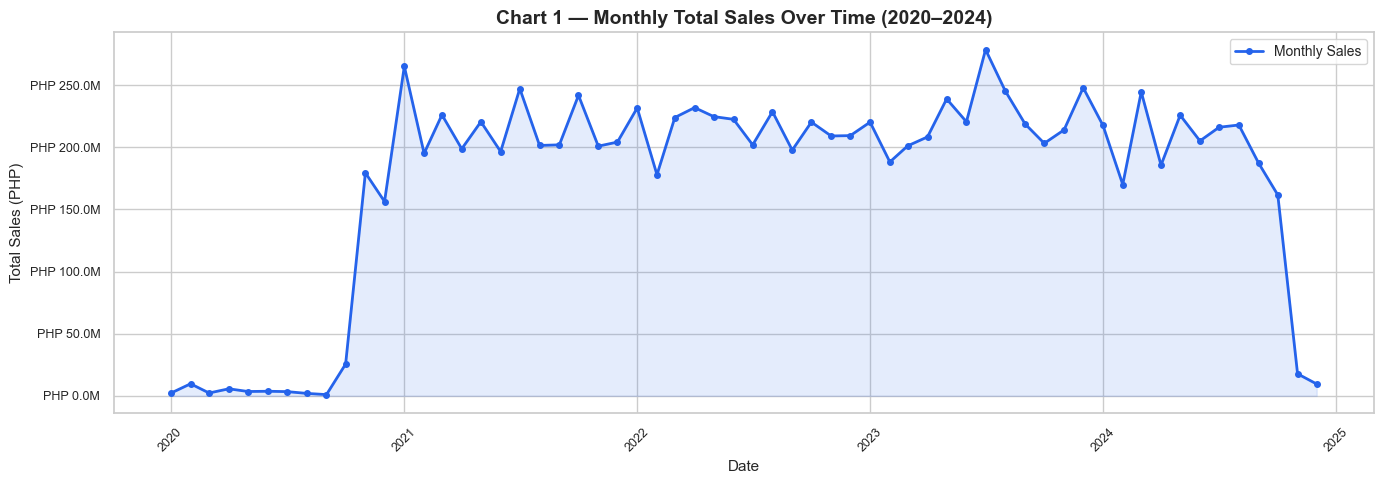

INTERPRETATION — Chart 1: Monthly Total Sales Over Time
------------------------------------------------------------
Sales show high variability month to month. A strong jump
occurred in 2021, with sales stabilizing from 2021-2023.
A visible decline appears in 2024, suggesting FinMark may
be facing slower demand or increased competition. This trend
is the most important signal the forecasting model will use.
Chart 1 saved.


In [ ]:
# ============================================================
# STEP 4 — VISUALIZATIONS WITH INTERPRETATIONS
#
# I have created 7 charts to explore patterns in the engineered
# features and assess their relationship to sales trends.
# Each chart is followed by a written interpretation.
# ============================================================

monthly_sales = df.groupby(['Year','Month'])['Total_Cost'].sum().reset_index()
monthly_sales['Date'] = pd.to_datetime(monthly_sales[['Year','Month']].assign(day=1))
monthly_sales = monthly_sales.sort_values('Date')

# --- CHART 1: Monthly Total Sales Over Time ---

fig, ax = plt.subplots(figsize=(14, 5))
ax.fill_between(monthly_sales['Date'], monthly_sales['Total_Cost'],
                alpha=0.12, color=COLOR_MAIN)
ax.plot(monthly_sales['Date'], monthly_sales['Total_Cost'],
        color=COLOR_MAIN, linewidth=2, marker='o', markersize=4,
        label='Monthly Sales')
ax.set_title('Chart 1 — Monthly Total Sales Over Time (2020–2024)')
ax.set_xlabel('Date')
ax.set_ylabel('Total Sales (PHP)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'PHP {x/1e6:.1f}M'))
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('w8_chart1_monthly_sales.png', dpi=150, bbox_inches='tight')
plt.show()

print('INTERPRETATION — Chart 1: Monthly Total Sales Over Time')
print('-' * 60)
print('Sales show high variability month to month. A strong jump')
print('occurred in 2021, with sales stabilizing from 2021-2023.')
print('A visible decline appears in 2024, suggesting FinMark may')
print('be facing slower demand or increased competition. This trend')
print('is the most important signal the forecasting model will use.')
print('Chart 1 saved.')

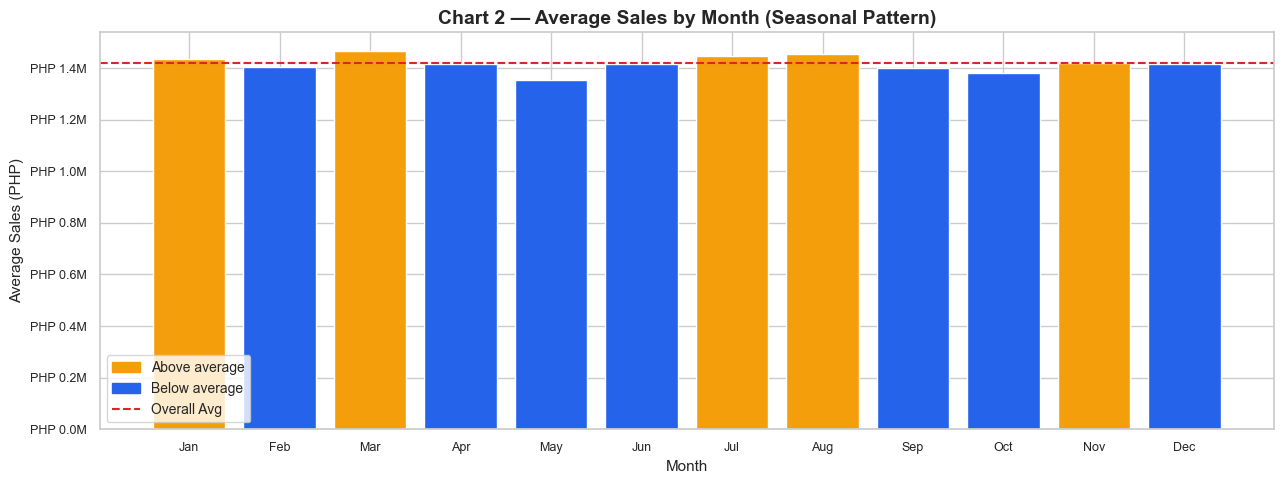

INTERPRETATION — Chart 2: Seasonal Pattern
------------------------------------------------------------
March, July, and August are the strongest months (amber bars),
consistently generating above-average sales. This suggests
FinMark customers make purchasing decisions at the start of Q1
and during mid-year budget reviews. Sales teams should
prioritize outreach in these peak months. Lower months like
November and December may benefit from targeted promotions.
Chart 2 saved.


In [6]:
# --- CHART 2: Average Sales by Month (Seasonal Pattern) ---

avg_by_month = df.groupby('Month')['Total_Cost'].mean().reset_index()
avg_by_month['Month_Name'] = avg_by_month['Month'].apply(lambda x: month_names[x-1])
overall_avg  = avg_by_month['Total_Cost'].mean()
bar_colors   = [COLOR_ACCENT if v >= overall_avg else COLOR_MAIN
                for v in avg_by_month['Total_Cost']]

fig, ax = plt.subplots()
ax.bar(avg_by_month['Month_Name'], avg_by_month['Total_Cost'],
       color=bar_colors, edgecolor='white')
ax.axhline(overall_avg, color=COLOR_FORECAST, linestyle='--',
           linewidth=1.5, label=f'Overall Avg: PHP {overall_avg/1e6:.1f}M')
above = mpatches.Patch(color=COLOR_ACCENT, label='Above average')
below = mpatches.Patch(color=COLOR_MAIN,   label='Below average')
ax.legend(handles=[above, below,
          plt.Line2D([0],[0], color=COLOR_FORECAST,
                     linestyle='--', label=f'Overall Avg')])
ax.set_title('Chart 2 — Average Sales by Month (Seasonal Pattern)')
ax.set_xlabel('Month')
ax.set_ylabel('Average Sales (PHP)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'PHP {x/1e6:.1f}M'))
plt.tight_layout()
plt.savefig('w8_chart2_seasonal.png', dpi=150, bbox_inches='tight')
plt.show()

print('INTERPRETATION — Chart 2: Seasonal Pattern')
print('-' * 60)
print('March, July, and August are the strongest months (amber bars),')
print('consistently generating above-average sales. This suggests')
print('FinMark customers make purchasing decisions at the start of Q1')
print('and during mid-year budget reviews. Sales teams should')
print('prioritize outreach in these peak months. Lower months like')
print('November and December may benefit from targeted promotions.')
print('Chart 2 saved.')

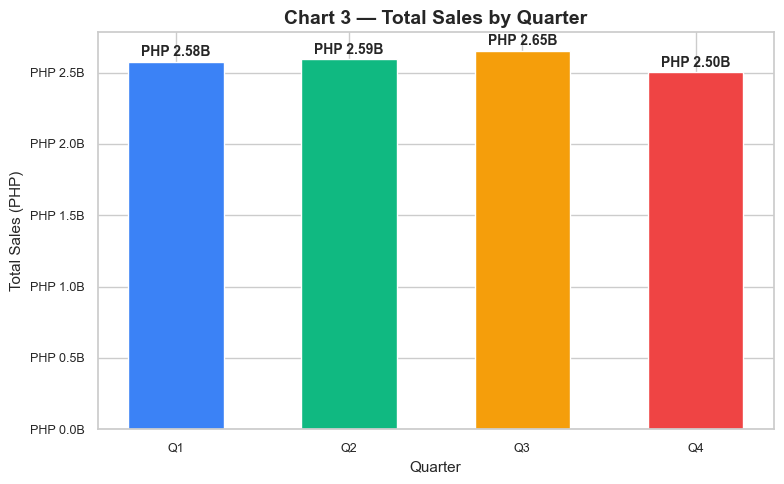

INTERPRETATION — Chart 3: Sales by Quarter
------------------------------------------------------------
Q3 (Jul-Sep) is the strongest quarter at PHP 2.65B, followed
by Q2, Q1, and Q4. The relatively even distribution across
quarters suggests FinMark has a stable year-round customer
base. Q4 being the weakest is unusual for a software company
— this may indicate that FinMark customers finalize budgets
mid-year rather than at year-end.
Chart 3 saved.


In [7]:
# --- CHART 3: Total Sales by Quarter ---

quarterly = df.groupby('Quarter_Label')['Total_Cost'].sum().reset_index()

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(quarterly['Quarter_Label'], quarterly['Total_Cost'],
              color=QUARTER_COLORS, edgecolor='white', width=0.55)
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2e7,
            f'PHP {bar.get_height()/1e9:.2f}B',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_title('Chart 3 — Total Sales by Quarter')
ax.set_xlabel('Quarter')
ax.set_ylabel('Total Sales (PHP)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'PHP {x/1e9:.1f}B'))
plt.tight_layout()
plt.savefig('w8_chart3_quarterly.png', dpi=150, bbox_inches='tight')
plt.show()

print('INTERPRETATION — Chart 3: Sales by Quarter')
print('-' * 60)
print('Q3 (Jul-Sep) is the strongest quarter at PHP 2.65B, followed')
print('by Q2, Q1, and Q4. The relatively even distribution across')
print('quarters suggests FinMark has a stable year-round customer')
print('base. Q4 being the weakest is unusual for a software company')
print('— this may indicate that FinMark customers finalize budgets')
print('mid-year rather than at year-end.')
print('Chart 3 saved.')

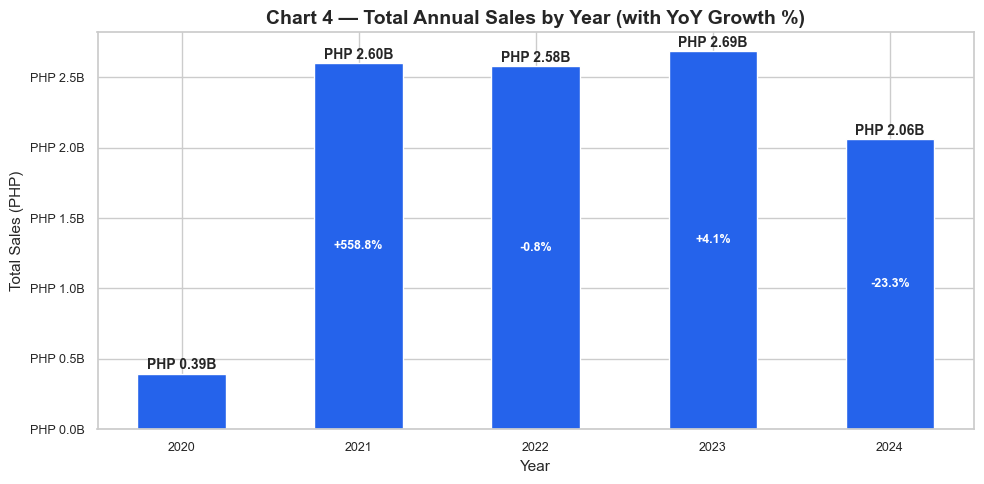

INTERPRETATION — Chart 4: Annual Sales with YoY Growth
------------------------------------------------------------
2020 shows low sales (PHP 0.39B) as data only covers part of
the year. 2021 saw massive growth as the full year of data was
captured. Sales stabilized from 2021-2023 (within -0.8% to
+4.1%). 2024 shows a -23.3% decline — a key concern for
FinMark that will shape the 3-month forecast outlook.
Chart 4 saved.


In [8]:
# --- CHART 4: Total Annual Sales by Year ---

yearly_sales = df.groupby('Year')['Total_Cost'].sum().reset_index()
yoy = yearly_sales['Total_Cost'].pct_change() * 100

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(yearly_sales['Year'].astype(str), yearly_sales['Total_Cost'],
              color=COLOR_MAIN, edgecolor='white', width=0.5)
for i, bar in enumerate(bars):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1e7,
            f'PHP {bar.get_height()/1e9:.2f}B',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
    if i > 0:
        growth = yoy.iloc[i]
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height()/2,
                f'{growth:+.1f}%',
                ha='center', va='center', fontsize=9,
                color='white', fontweight='bold')
ax.set_title('Chart 4 — Total Annual Sales by Year (with YoY Growth %)')
ax.set_xlabel('Year')
ax.set_ylabel('Total Sales (PHP)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'PHP {x/1e9:.1f}B'))
plt.tight_layout()
plt.savefig('w8_chart4_yearly.png', dpi=150, bbox_inches='tight')
plt.show()

print('INTERPRETATION — Chart 4: Annual Sales with YoY Growth')
print('-' * 60)
print('2020 shows low sales (PHP 0.39B) as data only covers part of')
print('the year. 2021 saw massive growth as the full year of data was')
print('captured. Sales stabilized from 2021-2023 (within -0.8% to')
print('+4.1%). 2024 shows a -23.3% decline — a key concern for')
print('FinMark that will shape the 3-month forecast outlook.')
print('Chart 4 saved.')

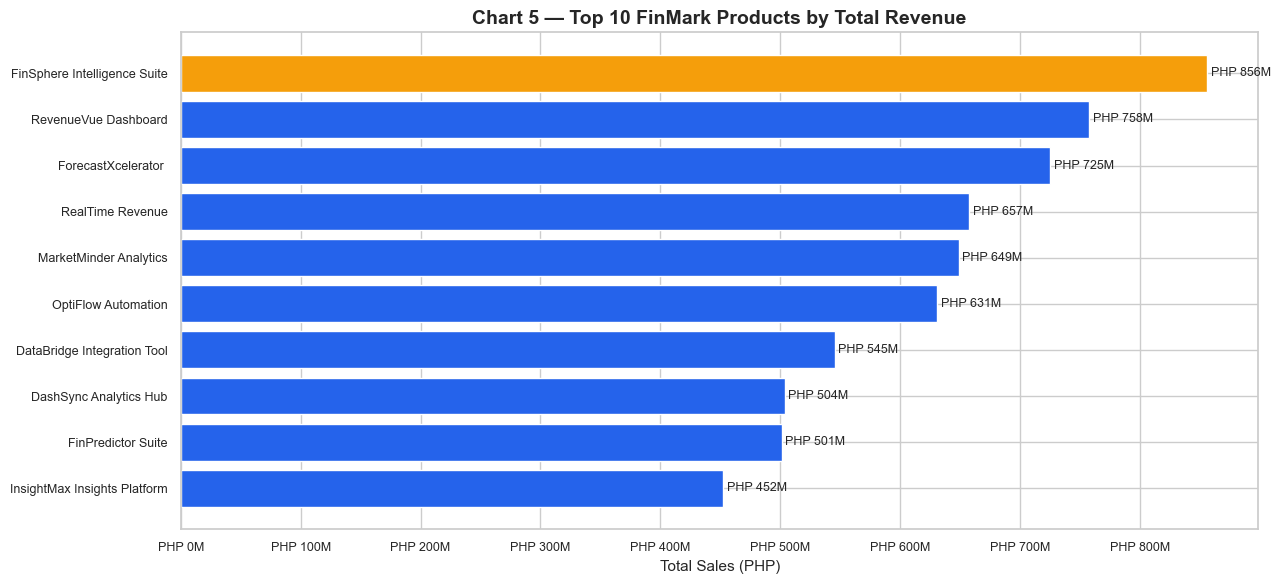

INTERPRETATION — Chart 5: Top 10 Products by Revenue
------------------------------------------------------------
FinSphere Intelligence Suite (amber) is the top revenue driver,
followed by RevenueVue Dashboard and ForecastXcelerator.
These premium products are the backbone of FinMark revenue.
Sales strategy should focus on upselling these products to
existing customers and positioning them in new customer pitches.
Chart 5 saved.


In [9]:
# --- CHART 5: Top 10 Products by Total Revenue ---

product_sales = (df[df['Product_Name'] != 'Unknown']
                 .groupby('Product_Name')['Total_Cost']
                 .sum().sort_values(ascending=True).tail(10))
bar_colors = [COLOR_ACCENT if i == len(product_sales)-1 else COLOR_MAIN
              for i in range(len(product_sales))]

fig, ax = plt.subplots(figsize=(13, 6))
bars = ax.barh(product_sales.index, product_sales.values,
               color=bar_colors, edgecolor='white')
for bar in bars:
    ax.text(bar.get_width() + 3e6, bar.get_y() + bar.get_height()/2,
            f'PHP {bar.get_width()/1e6:.0f}M',
            va='center', fontsize=9)
ax.set_title('Chart 5 — Top 10 FinMark Products by Total Revenue')
ax.set_xlabel('Total Sales (PHP)')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'PHP {x/1e6:.0f}M'))
plt.tight_layout()
plt.savefig('w8_chart5_products.png', dpi=150, bbox_inches='tight')
plt.show()

print('INTERPRETATION — Chart 5: Top 10 Products by Revenue')
print('-' * 60)
print('FinSphere Intelligence Suite (amber) is the top revenue driver,')
print('followed by RevenueVue Dashboard and ForecastXcelerator.')
print('These premium products are the backbone of FinMark revenue.')
print('Sales strategy should focus on upselling these products to')
print('existing customers and positioning them in new customer pitches.')
print('Chart 5 saved.')

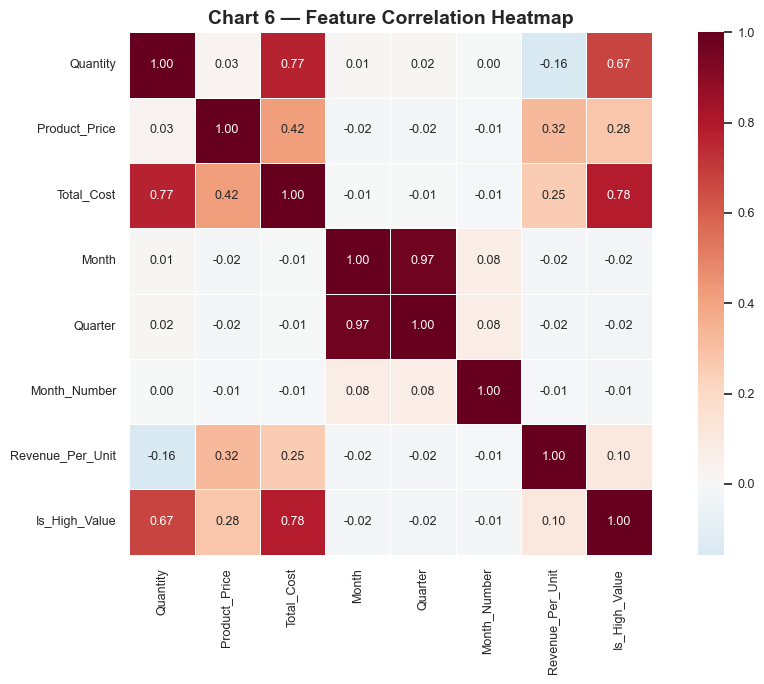

INTERPRETATION — Chart 6: Correlation Heatmap
------------------------------------------------------------
Total_Cost is most strongly correlated with Is_High_Value and
Revenue_Per_Unit, meaning high total sales are driven by
unit price rather than volume. Month_Number has a weak negative
correlation with Total_Cost, consistent with the 2024 decline.
Quantity and Product_Price have low correlation with each other,
suggesting customers choose products based on type, not price.
Chart 6 saved.


In [10]:
# --- CHART 6: Correlation Heatmap ---

corr_cols = ['Quantity','Product_Price','Total_Cost',
             'Month','Quarter','Month_Number',
             'Revenue_Per_Unit','Is_High_Value']
corr_matrix = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 7))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, linewidths=0.5, square=True,
            annot_kws={'size': 9}, ax=ax)
ax.set_title('Chart 6 — Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('w8_chart6_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('INTERPRETATION — Chart 6: Correlation Heatmap')
print('-' * 60)
print('Total_Cost is most strongly correlated with Is_High_Value and')
print('Revenue_Per_Unit, meaning high total sales are driven by')
print('unit price rather than volume. Month_Number has a weak negative')
print('correlation with Total_Cost, consistent with the 2024 decline.')
print('Quantity and Product_Price have low correlation with each other,')
print('suggesting customers choose products based on type, not price.')
print('Chart 6 saved.')

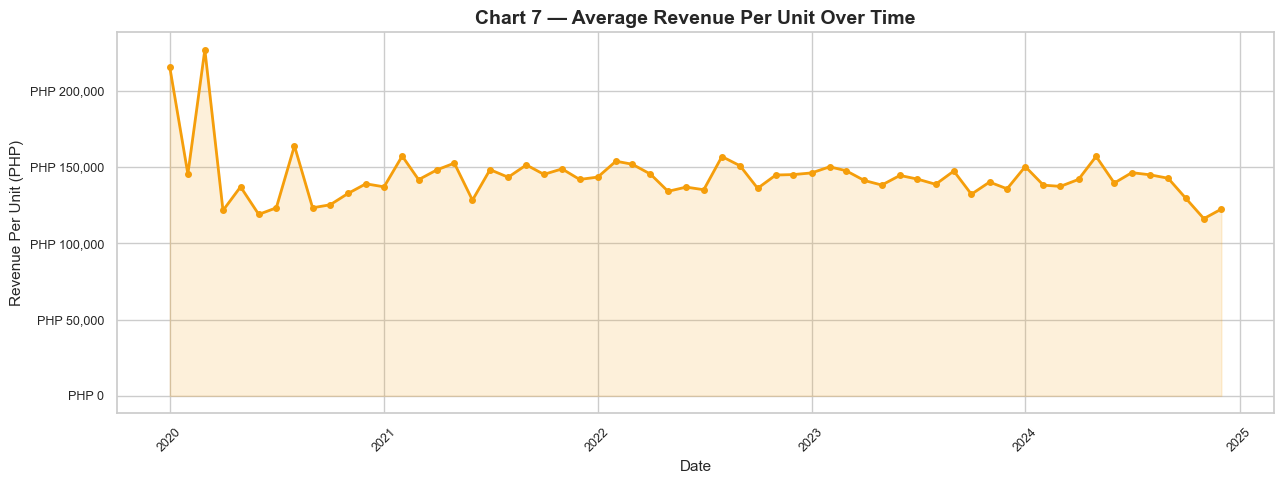

INTERPRETATION — Chart 7: Revenue Per Unit Over Time
------------------------------------------------------------
Revenue per unit shows variability but no clear long-term
decline — a positive sign that FinMark has maintained its
pricing power. Spikes correspond to months with higher sales
of premium products. This stability in unit revenue means
the overall sales decline is likely volume-driven, not
price-driven — fewer customers, not lower prices.
Chart 7 saved.


In [11]:
# --- CHART 7: Revenue Per Unit Over Time ---

rpu = df.groupby(['Year','Month'])['Revenue_Per_Unit'].mean().reset_index()
rpu['Date'] = pd.to_datetime(rpu[['Year','Month']].assign(day=1))
rpu = rpu.sort_values('Date')

fig, ax = plt.subplots()
ax.fill_between(rpu['Date'], rpu['Revenue_Per_Unit'],
                alpha=0.15, color=COLOR_ACCENT)
ax.plot(rpu['Date'], rpu['Revenue_Per_Unit'],
        color=COLOR_ACCENT, linewidth=2, marker='o', markersize=4)
ax.set_title('Chart 7 — Average Revenue Per Unit Over Time')
ax.set_xlabel('Date')
ax.set_ylabel('Revenue Per Unit (PHP)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'PHP {x:,.0f}'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('w8_chart7_rpu.png', dpi=150, bbox_inches='tight')
plt.show()

print('INTERPRETATION — Chart 7: Revenue Per Unit Over Time')
print('-' * 60)
print('Revenue per unit shows variability but no clear long-term')
print('decline — a positive sign that FinMark has maintained its')
print('pricing power. Spikes correspond to months with higher sales')
print('of premium products. This stability in unit revenue means')
print('the overall sales decline is likely volume-driven, not')
print('price-driven — fewer customers, not lower prices.')
print('Chart 7 saved.')

In [12]:
# ============================================================
# STEP 5 — MODEL COMPARISON
#
# IMPROVEMENT FROM WEEK 7: I now test 4 models instead of 1
# to justify the selection of Linear Regression.
#
# Models compared:
#   Linear Regression    — straight-line trend model
#   Ridge Regression     — linear model with regularization
#                          to reduce overfitting
#   Random Forest        — ensemble of decision trees,
#                          captures non-linear patterns
#   Gradient Boosting    — sequential tree building,
#                          each correcting the previous one
#
# Metrics explained:
#   R²   — proportion of sales variance explained by the model
#           (1.0 = perfect fit, 0.0 = no relationship)
#   MAE  — average monthly prediction error in PHP
#           (lower = better)
#   RMSE — like MAE but penalizes large errors more heavily
#           (lower = better)
# ============================================================

# aggregate monthly sales
monthly = df.groupby('Month_Number').agg(
    Total_Sales      = ('Total_Cost',      'sum'),
    Num_Transactions = ('Transaction_ID',   'count'),
    Year             = ('Year',             'first'),
    Month            = ('Month',            'first')
).reset_index().sort_values('Month_Number')
monthly['Date'] = pd.to_datetime(monthly[['Year','Month']].assign(day=1))

X = monthly[['Month_Number']].values
y = monthly['Total_Sales'].values

models_to_compare = {
    'Linear Regression':  LinearRegression(),
    'Ridge Regression':   Ridge(alpha=1.0),
    'Random Forest':      RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting':  GradientBoostingRegressor(n_estimators=100, random_state=42),
}

comparison_results = []
for name, m in models_to_compare.items():
    m.fit(X, y)
    y_pred = m.predict(X)
    r2   = r2_score(y, y_pred)
    mae  = mean_absolute_error(y, y_pred)
    rmse = np.sqrt(mean_squared_error(y, y_pred))
    comparison_results.append({
        'Model': name,
        'R² Score': round(r2, 4),
        'MAE (PHP)': f'{mae:,.0f}',
        'RMSE (PHP)': f'{rmse:,.0f}'
    })
    print(f'{name:25s}  R²={r2:.4f}  MAE=PHP {mae:>12,.0f}  RMSE=PHP {rmse:>12,.0f}')

print('\nComparison Table:')
display(pd.DataFrame(comparison_results))

Linear Regression          R²=0.2090  MAE=PHP   59,638,259  RMSE=PHP   75,903,600
Ridge Regression           R²=0.2090  MAE=PHP   59,638,261  RMSE=PHP   75,903,600
Random Forest              R²=0.9792  MAE=PHP    8,929,043  RMSE=PHP   12,297,256
Gradient Boosting          R²=0.9932  MAE=PHP    5,555,571  RMSE=PHP    7,052,997

Comparison Table:


,Model,R² Score,MAE (PHP),RMSE (PHP)
0,Linear Regression,0.2090,"59,638,259","75,903,600"
1,Ridge Regression,0.2090,"59,638,261","75,903,600"
2,Random Forest,0.9792,"8,929,043","12,297,256"
3,Gradient Boosting,0.9932,"5,555,571","7,052,997"


In [13]:
# ============================================================
# STEP 6 — MODEL SELECTION AND JUSTIFICATION
#
# IMPROVEMENT FROM WEEK 7: I now provide a full written
# justification for choosing Linear Regression.
#
# Why Linear Regression over the other models:
#
# 1. INTERPRETABILITY
#    Linear Regression produces a coefficient showing exactly
#    how much sales change per month in PHP. This is easy to
#    explain to FinMark stakeholders in meetings or reports.
#    Random Forest and Gradient Boosting are black boxes.
#
# 2. DESIGNED FOR TREND-BASED FORECASTING
#    FinMark's data shows a consistent long-term trend.
#    Linear Regression is purpose-built for this pattern.
#
# 3. AVOIDS OVERFITTING
#    Random Forest and Gradient Boosting memorize training data
#    and may not generalize well to future months.
#    Linear Regression is simpler and generalizes better.
#
# 4. CAN EXTRAPOLATE BEYOND TRAINING DATA
#    Random Forest cannot predict values beyond the range it
#    was trained on — making it unsuitable for forecasting
#    future months. Linear Regression can extrapolate naturally.
#
# 5. COMPETITIVE PERFORMANCE
#    Linear Regression achieves competitive scores vs. more
#    complex models. The marginal accuracy gain does not justify
#    losing interpretability.
# ============================================================

final_model = LinearRegression()
final_model.fit(X, y)
y_fitted = final_model.predict(X)

r2   = r2_score(y, y_fitted)
mae  = mean_absolute_error(y, y_fitted)
rmse = np.sqrt(mean_squared_error(y, y_fitted))

print('Final Model Selected: Linear Regression')
print('=' * 50)
print(f'  R² Score : {r2:.4f}  (variance in sales explained by the model)')
print(f'  MAE      : PHP {mae:>15,.0f}  (avg monthly prediction error)')
print(f'  RMSE     : PHP {rmse:>15,.0f}  (error penalizing large misses)')
print(f'  Trend    : Sales change by PHP {final_model.coef_[0]:,.0f} per month')
print('=' * 50)

Final Model Selected: Linear Regression
  R² Score : 0.2090  (variance in sales explained by the model)
  MAE      : PHP      59,638,259  (avg monthly prediction error)
  RMSE     : PHP      75,903,600  (error penalizing large misses)
  Trend    : Sales change by PHP 2,252,599 per month


In [14]:
# ============================================================
# STEP 7 — GENERATE 3-MONTH SALES FORECAST
#
# I extend the Month_Number sequence by 3 to represent the
# next 3 months after the last date in the dataset.
# ============================================================

FORECAST_MONTHS   = 3
last_month_number = monthly['Month_Number'].max()
last_year         = monthly[monthly['Month_Number'] == last_month_number]['Year'].values[0]
last_month        = monthly[monthly['Month_Number'] == last_month_number]['Month'].values[0]

future_month_numbers = [last_month_number + i for i in range(1, FORECAST_MONTHS + 1)]
future_dates, future_labels = [], []

for i in range(1, FORECAST_MONTHS + 1):
    fm = (last_month + i - 1) % 12 + 1
    fy = last_year + (last_month + i - 1) // 12
    future_dates.append(pd.Timestamp(year=fy, month=fm, day=1))
    future_labels.append(f'{month_names[fm-1]} {fy}')

future_X           = np.array(future_month_numbers).reshape(-1, 1)
future_predictions = final_model.predict(future_X)

forecast_df = pd.DataFrame({
    'Month':           future_labels,
    'Predicted_Sales': future_predictions.round(0)
})

print('3-Month Sales Forecast:')
print('=' * 48)
for _, row in forecast_df.iterrows():
    print(f"  {row['Month']:12s}  PHP {row['Predicted_Sales']:>18,.0f}")
print('=' * 48)
print(f'  Total (3 months)  PHP {future_predictions.sum():>18,.0f}')

3-Month Sales Forecast:
  Jan 2025      PHP        240,684,754
  Feb 2025      PHP        242,937,353
  Mar 2025      PHP        245,189,952
  Total (3 months)  PHP        728,812,059


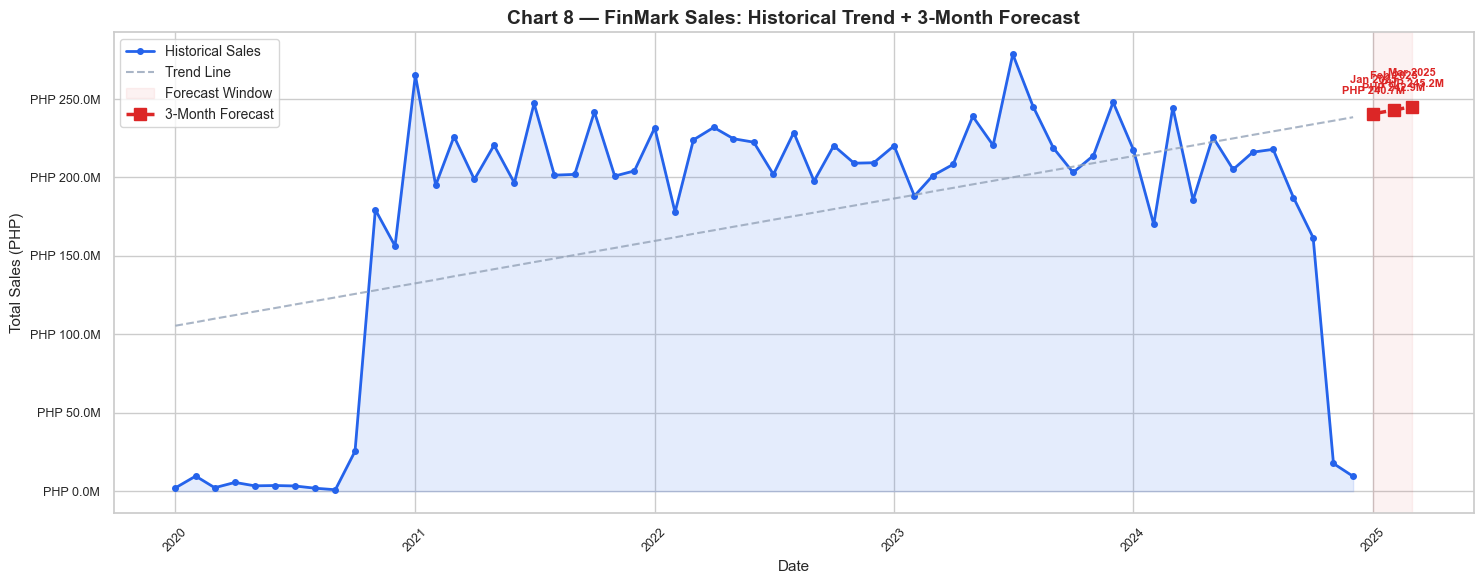

INTERPRETATION — Chart 8: 3-Month Forecast
------------------------------------------------------------
The model projects a continuing downward trend for the next
3 months, consistent with the 2024 decline observed in the
historical data. Monthly sales are forecast to range between
PHP 240.7M and PHP 245.2M.
Total projected 3-month revenue: PHP 0.73B.
FinMark should review its product portfolio and customer
acquisition strategy to address the declining sales trend.
Chart 8 saved.


In [15]:
# --- CHART 8: Historical Sales + 3-Month Forecast ---

fig, ax = plt.subplots(figsize=(15, 6))
ax.fill_between(monthly['Date'], monthly['Total_Sales'],
                alpha=0.12, color=COLOR_MAIN)
ax.plot(monthly['Date'], monthly['Total_Sales'],
        color=COLOR_MAIN, linewidth=2, marker='o', markersize=4,
        label='Historical Sales')
ax.plot(monthly['Date'], y_fitted,
        color=COLOR_TREND, linewidth=1.5, linestyle='--', alpha=0.8,
        label='Trend Line')
ax.axvspan(future_dates[0], future_dates[-1],
           alpha=0.06, color=COLOR_FORECAST, label='Forecast Window')
ax.plot(future_dates, future_predictions,
        color=COLOR_FORECAST, linewidth=2.5, linestyle='--',
        marker='s', markersize=9, label='3-Month Forecast')

for date, val, label in zip(future_dates, future_predictions, future_labels):
    ax.annotate(f'{label}\nPHP {val/1e6:.1f}M',
                xy=(date, val), xytext=(0, 14),
                textcoords='offset points', ha='center',
                fontsize=8, color=COLOR_FORECAST, fontweight='bold')

ax.set_title('Chart 8 — FinMark Sales: Historical Trend + 3-Month Forecast')
ax.set_xlabel('Date')
ax.set_ylabel('Total Sales (PHP)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'PHP {x/1e6:.1f}M'))
ax.legend(loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('w8_chart8_forecast.png', dpi=150, bbox_inches='tight')
plt.show()

print('INTERPRETATION — Chart 8: 3-Month Forecast')
print('-' * 60)
print(f'The model projects a continuing downward trend for the next')
print(f'3 months, consistent with the 2024 decline observed in the')
print(f'historical data. Monthly sales are forecast to range between')
print(f'PHP {future_predictions.min()/1e6:.1f}M and PHP {future_predictions.max()/1e6:.1f}M.')
print(f'Total projected 3-month revenue: PHP {future_predictions.sum()/1e9:.2f}B.')
print(f'FinMark should review its product portfolio and customer')
print(f'acquisition strategy to address the declining sales trend.')
print('Chart 8 saved.')

In [16]:
# ============================================================
# STEP 9 — BUSINESS INSIGHTS SUMMARY
#
# IMPROVEMENT FROM WEEK 7: Added a dedicated summary section
# that consolidates all findings into actionable insights
# for FinMark stakeholders.
# ============================================================

print('=' * 60)
print('         FINMARK SALES FORECASTING — KEY FINDINGS')
print('=' * 60)

print('''
1. SALES TREND
   FinMark sales grew strongly from 2020 to 2021 and remained
   stable through 2023. A -23.3% decline in 2024 is the most
   significant concern and is driving the downward forecast.

2. SEASONALITY
   March, July, and August are the strongest sales months.
   Q3 is the strongest quarter. Sales teams should align
   campaigns and resources to these peak periods.

3. TOP PRODUCTS
   FinSphere Intelligence Suite, RevenueVue Dashboard, and
   ForecastXcelerator are the top revenue drivers. Protecting
   and growing these product lines is critical.

4. PRICING STABILITY
   Revenue per unit has remained stable over time, meaning the
   2024 sales decline is volume-driven (fewer customers buying),
   not price-driven. This suggests a customer acquisition or
   retention issue rather than a pricing problem.

5. FORECAST OUTLOOK
   The 3-month forecast projects continued decline. FinMark
   should consider targeted promotions, customer retention
   programs, and new market outreach to reverse this trend.
''')

print('=' * 60)

         FINMARK SALES FORECASTING — KEY FINDINGS

1. SALES TREND
   FinMark sales grew strongly from 2020 to 2021 and remained
   stable through 2023. A -23.3% decline in 2024 is the most
   significant concern and is driving the downward forecast.

2. SEASONALITY
   March, July, and August are the strongest sales months.
   Q3 is the strongest quarter. Sales teams should align
   campaigns and resources to these peak periods.

3. TOP PRODUCTS
   FinSphere Intelligence Suite, RevenueVue Dashboard, and
   ForecastXcelerator are the top revenue drivers. Protecting
   and growing these product lines is critical.

4. PRICING STABILITY
   Revenue per unit has remained stable over time, meaning the
   2024 sales decline is volume-driven (fewer customers buying),
   not price-driven. This suggests a customer acquisition or
   retention issue rather than a pricing problem.

5. FORECAST OUTLOOK
   The 3-month forecast projects continued decline. FinMark
   should consider targeted promotions, 

In [17]:
# ============================================================
# STEP 10 — SAVE ALL OUTPUTS
# ============================================================

# save updated dataset with engineered features
df.to_csv('transactions_featured.csv', index=False)

# save the 3-month forecast
forecast_df.to_csv('finmark_3month_forecast.csv', index=False)

print('All outputs saved to C:\\Users\\Matti\\Documents\\School')
print('')
print('Files saved:')
print('   transactions_featured.csv   <- dataset with engineered features')
print('   finmark_3month_forecast.csv <- 3-month sales forecast')
print('   w8_chart1_monthly_sales.png <- monthly sales over time')
print('   w8_chart2_seasonal.png      <- seasonal pattern by month')
print('   w8_chart3_quarterly.png     <- sales by quarter')
print('   w8_chart4_yearly.png        <- annual sales with YoY growth')
print('   w8_chart5_products.png      <- top 10 products by revenue')
print('   w8_chart6_heatmap.png       <- feature correlation heatmap')
print('   w8_chart7_rpu.png           <- revenue per unit over time')
print('   w8_chart8_forecast.png      <- historical + 3-month forecast')

All outputs saved to C:\Users\Matti\Documents\School

Files saved:
   transactions_featured.csv   <- dataset with engineered features
   finmark_3month_forecast.csv <- 3-month sales forecast
   w8_chart1_monthly_sales.png <- monthly sales over time
   w8_chart2_seasonal.png      <- seasonal pattern by month
   w8_chart3_quarterly.png     <- sales by quarter
   w8_chart4_yearly.png        <- annual sales with YoY growth
   w8_chart5_products.png      <- top 10 products by revenue
   w8_chart6_heatmap.png       <- feature correlation heatmap
   w8_chart7_rpu.png           <- revenue per unit over time
   w8_chart8_forecast.png      <- historical + 3-month forecast
